packages

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg
from PIL import Image
import os

In [9]:
!pip install kaggle


<a name='1'></a>
# Application of Eigenvalues and Eigenvectors: Navigating Webpages (Markov Matrix)

Eigenvalues and eigenvectors play a crucial role in **discrete dynamical systems**, where the state of a system evolves step by step according to a fixed process.  



## Discrete Dynamical Systems

A discrete dynamical system describes how a system’s state changes over time. We represent the set of possible states in a **state vector**. For example:
- States: `sunny`, `rainy`, `cloudy`
- State vector: encodes probabilities for being in each state.

The dynamics are governed by a **transition matrix** $P$, where each entry $p_{ij}$ represents the probability of moving from state $j$ to state $i$.  

- The element $(2,1)$ = probability of transitioning *from state 1 to state 2*.  
- Each column forms a probability distribution (sums to 1).

Given an initial state $X_0$, the evolution is:

$$
X_1 = P X_0, \quad X_2 = P^2 X_0, \quad X_3 = P^3 X_0, \ldots
$$

In general:

$$
X_t = P X_{t-1}, \quad t = 0, 1, 2, \dots
$$




## Example: Browsing Web Pages

We can use this framework to model **web navigation**. Suppose a browser visits pages by following links between them:
- The **state vector** $X_t$ = probability distribution of being on each page at time $t$.  
- The **transition matrix** $P$ = probabilities of moving between pages.

For simplicity, assume there are $n = 5$ pages.  
We construct a $5 \times 5$ transition matrix $P$, with:
- Zeros on the diagonal (no self-links),
- Each column summing to 1 (valid probability distribution).

$$
P =
\begin{bmatrix}
0    & 0.75 & 0.35 & 0.25 & 0.85 \\
0.15 & 0    & 0.35 & 0.25 & 0.05 \\
0.15 & 0.15 & 0    & 0.25 & 0.05 \\
0.15 & 0.05 & 0.05 & 0    & 0.05 \\
0.55 & 0.05 & 0.25 & 0.25 & 0
\end{bmatrix}
$$




In [3]:
P = np.array([ 
    
    [0, 0.75, 0.35, 0.25, 0.85], 
    [0.15, 0, 0.35, 0.25, 0.05], 
    [0.15, 0.15, 0, 0.25, 0.05], 
    [0.15, 0.05, 0.05, 0, 0.05], 
    [0.55, 0.05, 0.25, 0.25, 0]  
]) 

X0 = np.array([[0],[0],[0],[1],[0]])
# Multiply matrix P and X_0 (matrix multiplication).
X1 = P@X0
print(f'Sum of columns of P: {sum(P)}')
print(f'X1:\n{X1}')

Sum of columns of P: [1. 1. 1. 1. 1.]
X1:
[[0.25]
 [0.25]
 [0.25]
 [0.  ]
 [0.25]]


Applying the transformation $m$ times you can find a vector $X_m$ with the probabilities of the browser being at each of the pages after $m$ steps of navigation.

## Long-Term Behavior

Suppose the browser starts at page 4:

$$
X_0 = [0, 0, 0, 1, 0]^T
$$  

After one step:

$$
X_1 = P X_0
$$  

After $m$ steps:

$$
X_m = P^m X_0
$$  

For large $m$, we want to know which pages get the most traffic.  
Instead of computing $P^m$ repeatedly, we can use **eigenvalues and eigenvectors**.



In [4]:
X = np.array([[0],[0],[0],[1],[0]])
m = 20

for t in range(m):
    X = P @ X
    
print(X)

[[0.39392366]
 [0.13392366]
 [0.11407667]
 [0.0850993 ]
 [0.27297672]]


## Markov Matrices and Eigenvalues

A **Markov matrix** (also called a *stochastic matrix*) is a square matrix with:
1. Nonnegative entries,  
2. Each column summing to 1.  

**Key property:**  
Every Markov matrix has an eigenvalue equal to **1**.  

- The **eigenvector corresponding to eigenvalue 1** represents the **steady-state distribution** of the system.  
- For large $m$, the system evolves toward this eigenvector, regardless of the initial state.  

Thus, instead of repeatedly multiplying $P$, we can directly compute the **eigenvector for eigenvalue = 1** to find the long-run probabilities of being on each page.

In [5]:
eigenvals, eigenvecs = np.linalg.eig(P)
print(f'Eigenvalues of P:\n{eigenvals}\n\nEigenvectors of P\n{eigenvecs}')
X_inf = eigenvecs[:,0]

print(f"Eigenvector corresponding to the eigenvalue 1:\n{X_inf[:,np.newaxis]}")

Eigenvalues of P:
[ 1.         -0.70367062  0.00539505 -0.08267227 -0.21905217]

Eigenvectors of P
[[-0.76088562 -0.81362074  0.10935376  0.14270615 -0.39408574]
 [-0.25879453  0.050269   -0.6653158   0.67528802 -0.66465044]
 [-0.2204546   0.07869601 -0.29090665  0.17007443  0.35048734]
 [-0.1644783   0.12446953  0.19740707 -0.43678067  0.23311487]
 [-0.52766004  0.56018621  0.64946163 -0.55128793  0.47513398]]
Eigenvector corresponding to the eigenvalue 1:
[[-0.76088562]
 [-0.25879453]
 [-0.2204546 ]
 [-0.1644783 ]
 [-0.52766004]]


<a name='2'></a>
## 2 - Application of Eigenvalues and Eigenvectors: Principal Component Analysis

Another important application of eigenvalues and eigenvectors is **Principal Component Analysis (PCA)**.  

We will apply PCA on an image dataset to perform **image compression**, using the [Cat and Dog Face dataset](https://www.kaggle.com/datasets/alessiosanna/cat-dog-64x64-pixel/data) and focusing on the cat images.

To apply PCA:  
1. Build the covariance matrix.  
2. Compute eigenvalues and eigenvectors.  
3. Keep the top $k$ eigenvectors (principal components).  
4. Project the data onto these components.

<a name='2.1'></a>
### 2.1 - Load the Data

Each 64×64 grayscale image has 4096 pixels. Flatten each image into a row vector using NumPy `reshape`.  
The dataset will then have 55 rows (images) and 4096 columns (pixels).

$$
\text{imgs\_flatten} \in \mathbb{R}^{55 \times 4096}
$$

<a name='2.2'></a>



Dataset shape: (55, 64, 64)
Flattened shape: (55, 4096)


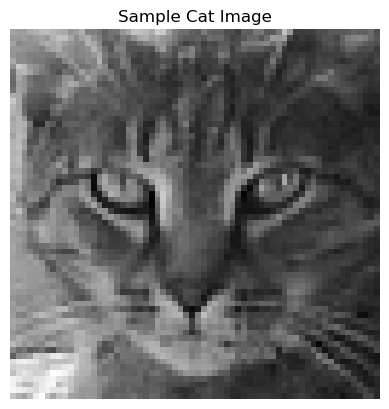

In [34]:
# Path to the cat folder
data_dir = "./CatDog"

# print(os.getcwd())
# print(os.listdir("./"))
# print(os.listdir("./CatDog"))

# Load only files that start with "cat"
images = []
for file in os.listdir(data_dir):
    if file.lower().startswith("cat") and (file.endswith(".jpg") or file.endswith(".png")):
        img_path = os.path.join(data_dir, file)
        img = Image.open(img_path).convert("L")  # grayscale
        img = img.resize((64, 64))  # ensure consistent size
        images.append(np.array(img))

images = np.array(images)
print("Dataset shape:", images.shape)

# Flatten for PCA
imgs_flatten = images.reshape(images.shape[0], -1)
print("Flattened shape:", imgs_flatten.shape)

# Show a sample
plt.imshow(images[54], cmap="gray")
plt.title("Sample Cat Image")
plt.axis("off")
plt.show()

In [ ]:
#same for dogs
dogs = []
for file in os.listdir(data_dir):
    if file.lower().startswith("dog") and (file.endswith(".jpg") or file.endswith(".png")):
        img_path = os.path.join(data_dir, file)
        img = Image.open(img_path).convert("L")
        img = img.resize((64, 64))
        dogs.append(np.array(img))

dogs = np.array(dogs)
print("Dog dataset shape:", dogs.shape)


Dog dataset shape: (55, 64, 64)


### 2.2 Centering the Data

Treat each pixel as a variable $X_1, X_2, \ldots, X_{4096}$ and each image as an observation. The dataset looks like:

$$
\mathrm{imgs\_flatten} =
\begin{bmatrix}
x_{1,1} & x_{1,2} & \ldots & x_{1,4096} \\
x_{2,1} & x_{2,2} & \ldots & x_{2,4096} \\
\vdots  & \vdots  & \ddots & \vdots     \\
x_{55,1} & x_{55,2} & \ldots & x_{55,4096}
\end{bmatrix}
$$



<a name='ex03'></a>


Before computing $\Sigma$, subtract the mean of each column. The centered data $X$ is:

$$
X =
\begin{bmatrix}
(x_{1,1}-\mu_1) & (x_{1,2}-\mu_2) & \ldots & (x_{1,4096}-\mu_{4096}) \\
(x_{2,1}-\mu_1) & (x_{2,2}-\mu_2) & \ldots & (x_{2,4096}-\mu_{4096}) \\
\vdots & \vdots & \ddots & \vdots \\
(x_{55,1}-\mu_1) & (x_{55,2}-\mu_2) & \ldots & (x_{55,4096}-\mu_{4096})
\end{bmatrix}
$$

For example, the mean of the first pixel is:

$$
\mu_1 = \frac{1}{55} \sum_{i=1}^{55} x_{i,1}
$$


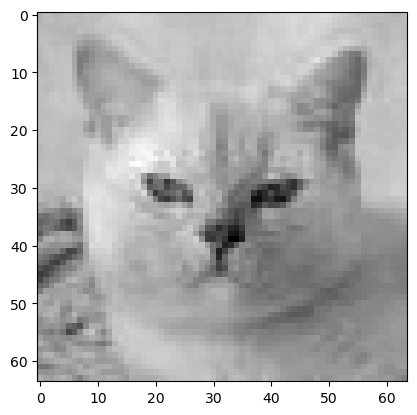

In [48]:
def center_data(Y):
    """
    Center your original data
    Args:
         Y (ndarray): input data. Shape (n_observations x n_pixels)
    Outputs:
        X (ndarray): centered data
    """
    # Subtract the mean
    X = Y - np.mean(Y, axis=0)
    return X


X = center_data(imgs_flatten)

plt.imshow(X[0].reshape(64,64), cmap='gray')

### Why Center the Data?

Centering means subtracting the mean of each variable (pixel) so that the new data has zero mean.  

This step is important because:

1. **Covariance definition**:  
   The covariance between two variables $X$ and $Y$ is  
   $$
   Cov(X, Y) = \frac{1}{n-1} \sum_{i=1}^n (x_i - \mu_X)(y_i - \mu_Y)
   $$
   If we don’t subtract the mean, we are not really measuring how the variables *co-vary* relative to their averages.

2. **Interpretability**:  
   Without centering, the covariance matrix mixes the information about the means and the variability, which can bias the results.

3. **PCA requirement**:  
   PCA relies on eigenvectors of the covariance matrix. If the data is not centered, the first principal component might just point toward the mean of the data, instead of capturing the direction of maximum variance.

In short: **centering removes bias due to nonzero means, ensuring the covariance matrix reflects only variance and correlation.**


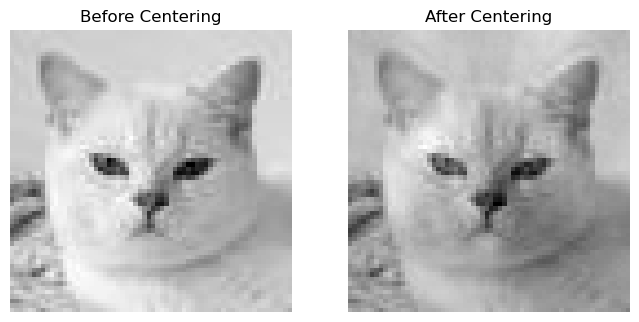

In [49]:
# Original first cat image
original_img = imgs_flatten[0].reshape(64, 64)

# Centered first cat image
centered_img = X[0].reshape(64, 64)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Before Centering")
axes[0].axis("off")

axes[1].imshow(centered_img, cmap='gray')
axes[1].set_title("After Centering")
axes[1].axis("off")

plt.show()


## 2.3 - Covariance Matrix

Once we have the centered data $X$, we can compute the covariance matrix.  

The covariance matrix is obtained by taking the dot product of $X^T$ and $X$, and then dividing by the number of observations minus one:

$$
\Sigma = \frac{1}{n-1} X^T X
$$

where $n$ is the number of observations (images).  

The covariance matrix $\Sigma$ then gives:

$$
\Sigma =
\begin{bmatrix}
Var(X_1) & Cov(X_1,X_2) & \ldots & Cov(X_1,X_{4096}) \\
Cov(X_1,X_2) & Var(X_2) & \ldots & Cov(X_2,X_{4096}) \\
\vdots & \vdots & \ddots & \vdots \\
Cov(X_1,X_{4096}) & Cov(X_2,X_{4096}) & \ldots & Var(X_{4096})
\end{bmatrix}
$$

This gives us a $(4096 \times 4096)$ covariance matrix when working with flattened 64×64 images.


In [53]:
def get_cov_matrix(X):
    """ Calculate covariance matrix from centered data X
    Args:
        X (np.ndarray): centered data matrix
    Outputs:
        cov_matrix (np.ndarray): covariance matrix
    """

    cov_matrix = (X.T @ X) / (X.shape[0] - 1)
    
    return cov_matrix

cov_matrix = get_cov_matrix(X)
# Check the dimensions of the covariance matrix, it should be a square matrix with 4096 rows and columns. 
print(f'Covariance matrix shape: {cov_matrix.shape}')

Covariance matrix shape: (4096, 4096)


<a name='2.3'></a>
## 2.4 - Compute the Eigenvalues and Eigenvectors

Now we can compute the eigenvalues and eigenvectors of the covariance matrix.  

For performance reasons we will not use `np.linalg.eig`, but instead [`scipy.sparse.linalg.eigsh`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html). This function:
- Exploits the fact that $\mathrm{cov\_matrix}^T = \mathrm{cov\_matrix}$ (symmetric).
- Lets us compute only the largest $k$ eigenvalues and eigenvectors, which is much faster.

Since our dataset has 55 observations, at most **55 eigenvalues** of the covariance matrix are nonzero. For efficiency, we will compute the top 55 eigenvalues $\lambda_1, \ldots, \lambda_{55}$ and corresponding eigenvectors $v_1, \ldots, v_{55}$.  

If you try setting `k > 55`, you will see that the extra eigenvalues are zero. Keep `k` below ~80, otherwise it may take too long.  

One detail:  
- `eigsh` returns eigenvalues in **ascending order**.  
- To match the usual PCA convention (largest first), we will reverse the order of `eigenvals` and `eigenvecs`.

Remember:  
- Each eigenvector is a **principal component**.  
- The eigenvector with the largest eigenvalue = **first principal component**.  
- The next eigenvector = **second principal component**, and so on.  

Note that eigenvectors are unique up to a sign flip. For example:

$$
\begin{bmatrix} 0.25 \\ 0.25 \\ -0.25 \\ 0.25 \end{bmatrix}
\quad \text{and} \quad
\begin{bmatrix} -0.25 \\ -0.25 \\ 0.25 \\ -0.25 \end{bmatrix}
$$

both represent the same direction. To keep results consistent, we fix the random seed.




In [56]:
from scipy.sparse.linalg import eigsh

# Fix random seed for reproducibility
np.random.seed(7)

# Compute top 55 eigenvalues and eigenvectors
eigenvals, eigenvecs = eigsh(cov_matrix, k=55)

# Reverse order so largest eigenvalue is first
eigenvals = eigenvals[::-1]
eigenvecs = eigenvecs[:, ::-1]

print("Ten largest eigenvalues:\n", eigenvals[:10])


Ten largest eigenvalues:
 [4331503.47066011 2481971.17880371 1546703.59197482 1001362.38077059
  860198.13534498  823781.21768573  463466.05134191  414697.44424484
  372686.03337896  297924.71221461]


Each principal component usually extracts some relevant features, or patterns from each image. In the next step, we will visualize the first 16 principal components to see the features they capture.

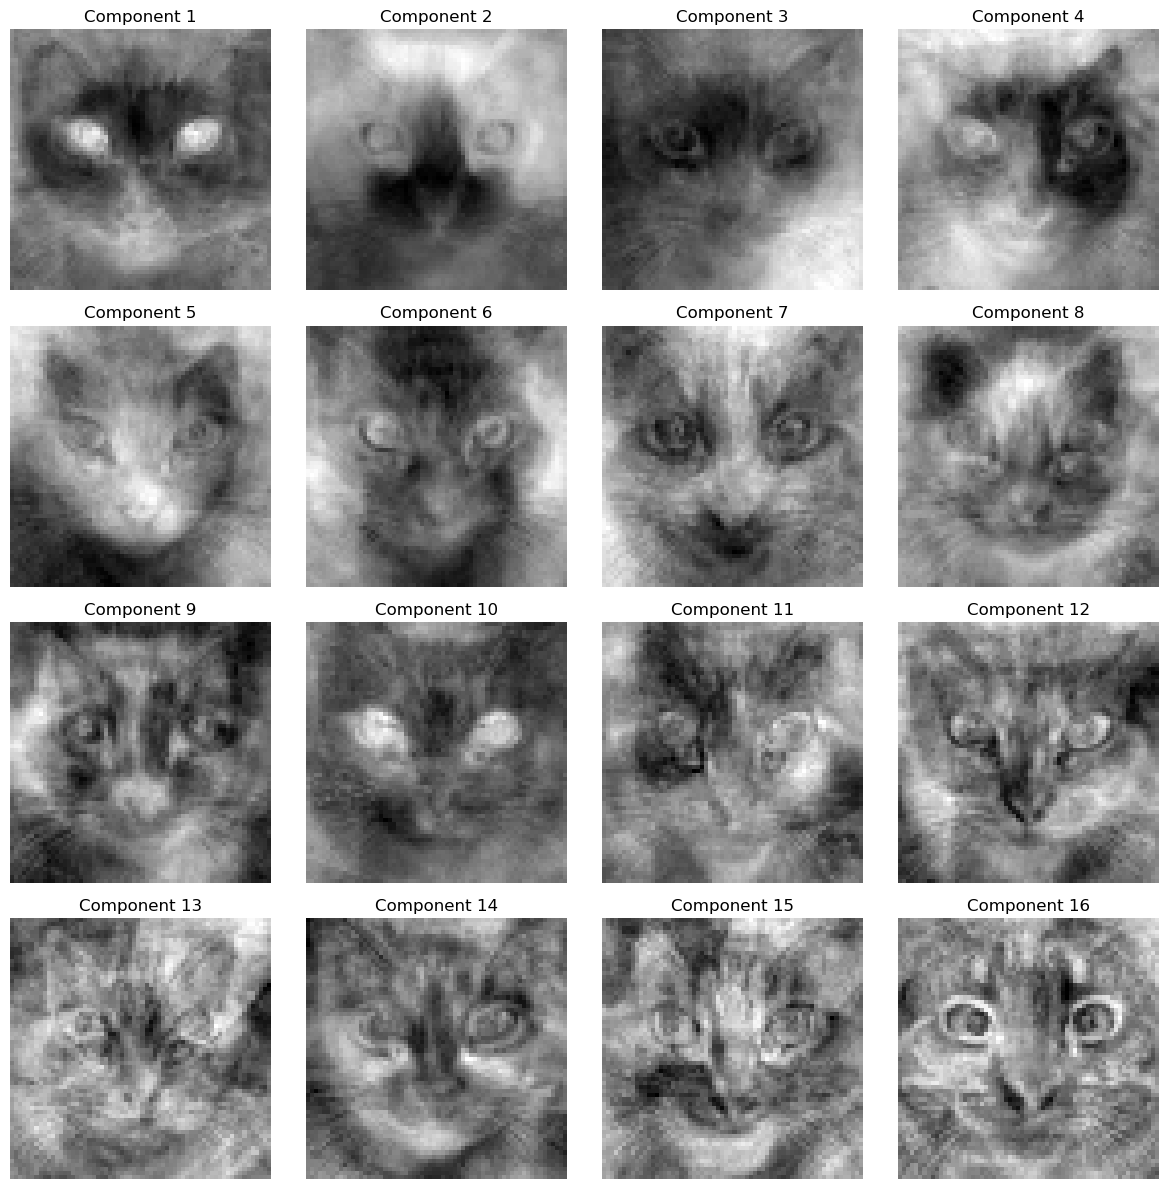

In [58]:
height, width = 64, 64  # image dimensions

fig, ax = plt.subplots(4, 4, figsize=(12, 12))
for n in range(4):
    for k in range(4):
        idx = n * 4 + k
        component = eigenvecs[:, idx].reshape(height, width)
        
        # Normalize for better visualization
        component_display = (component - component.min()) / (component.max() - component.min())
        
        ax[n, k].imshow(component_display, cmap='gray')
        ax[n, k].set_title(f'Component {idx+1}')
        ax[n, k].axis("off")

plt.tight_layout()
plt.show()


<a name='2.5'></a>
### 2.5 - Transform the Centered Data with PCA

Now that we have the first 55 eigenvalue–eigenvector pairs, we can use them to reduce the dimensionality of our data.  

Originally, each image had **4096 variables** (pixels). If we want to reduce to just 2 dimensions, we take the first two principal components $v_1$ and $v_2$, and form the matrix:

$$
\mathbf{V} =
\begin{bmatrix}
v_1 & v_2
\end{bmatrix}
$$

The reduced representation of the data is then obtained by projecting the centered data $X$ onto $\mathbf{V}$:

$$
X_{\text{reduced}} = X \cdot \mathbf{V}
$$

In the next step, we will implement a function that performs this projection for any number of components.


In [60]:
def perform_PCA(X, eigenvecs, k):
    """
    Perform dimensionality reduction with PCA
    Inputs:
        X (ndarray): original data matrix. Has dimensions (n_observations)x(n_variables)
        eigenvecs (ndarray): matrix of eigenvectors. Each column is one eigenvector. The k-th eigenvector 
                            is associated to the k-th eigenvalue
        k (int): number of principal components to use
    Returns:
        Xred
    """
    
    V = eigenvecs[:, :k]  
    Xred = X @ V 
    return Xred

Xred2 = perform_PCA(X, eigenvecs,2)
print(f'Xred2 shape: {Xred2.shape}')

Xred2 shape: (55, 2)


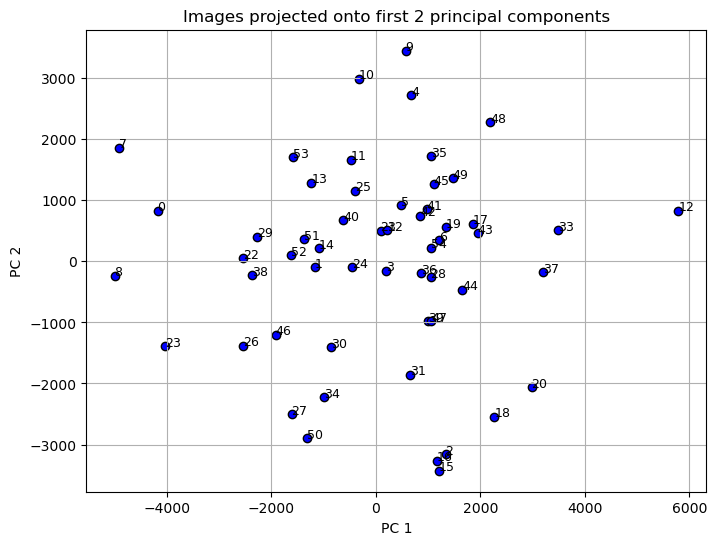

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Xred2[:,0], Xred2[:,1], c='blue', edgecolor='k')

# Add image indices next to each point
for i in range(Xred2.shape[0]):
    plt.text(Xred2[i,0] + 0.02, Xred2[i,1] + 0.02, str(i), fontsize=9)

plt.title("Images projected onto first 2 principal components")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()



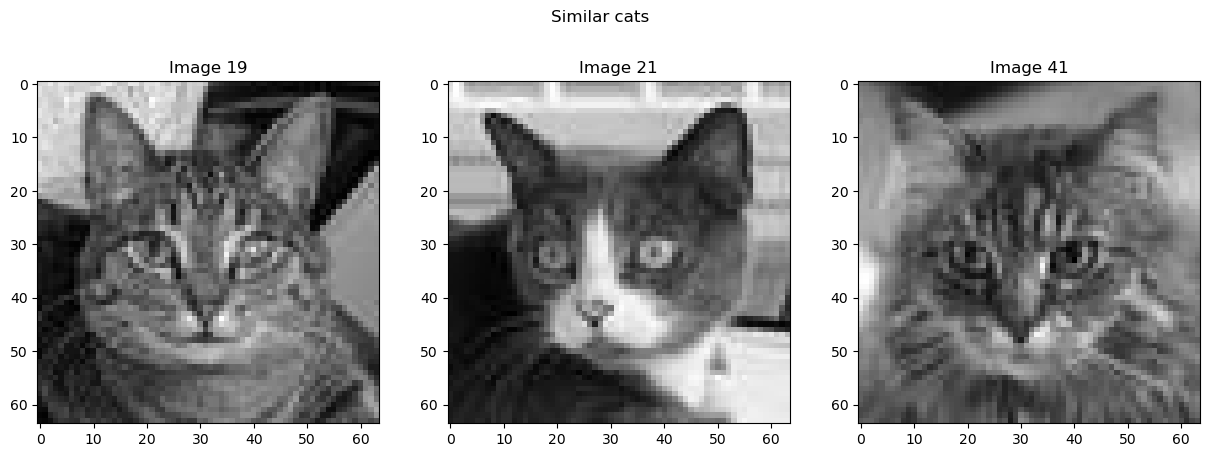

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(images[45], cmap='gray')
ax[0].set_title('Image 19')
ax[1].imshow(images[35], cmap='gray')
ax[1].set_title('Image 21')
ax[2].imshow(images[49], cmap='gray')
ax[2].set_title('Image 41')
plt.suptitle('Similar cats')
plt.show()


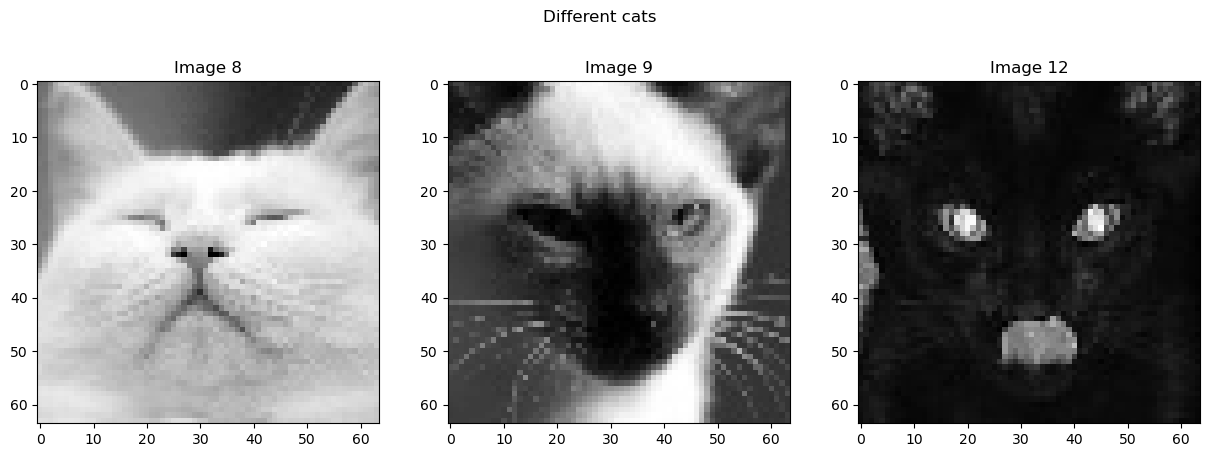

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(images[8], cmap='gray')
ax[0].set_title('Image 8')
ax[1].imshow(images[9], cmap='gray')
ax[1].set_title('Image 9')
ax[2].imshow(images[12], cmap='gray')
ax[2].set_title('Image 12')

plt.suptitle('Different cats')
plt.show()

<a name='2.6'></a>
### 2.6 - Reconstructing the Images from the Eigenvectors

When we compress images using PCA, we lose information by keeping only a subset of the components.  
The key question is: **how many components are enough for a good reconstruction?**

With PCA, we can project back into the original pixel space using the eigenvectors we kept.  

If we reduce the data to 2 components:
$$
X_{\text{red}} = X \cdot V_2, \quad \text{where } V_2 = [v_1\ v_2]
$$

To reconstruct the images, we transform back:
$$
X_{\text{rec}} = X_{\text{red}} \cdot V_2^T
$$

For $k$ components, we use:
$$
V_k = [v_1\ v_2 \ \ldots\ v_k], \quad 
X_{\text{rec}} = X_{\text{red}} \cdot V_k^T
$$

Note: you must use the same $k$ eigenvectors that were used to form $X_{\text{red}}$. Otherwise, the dimensions will not match for matrix multiplication.


Text(0.5, 1.0, 'reconstructed from 30 components')

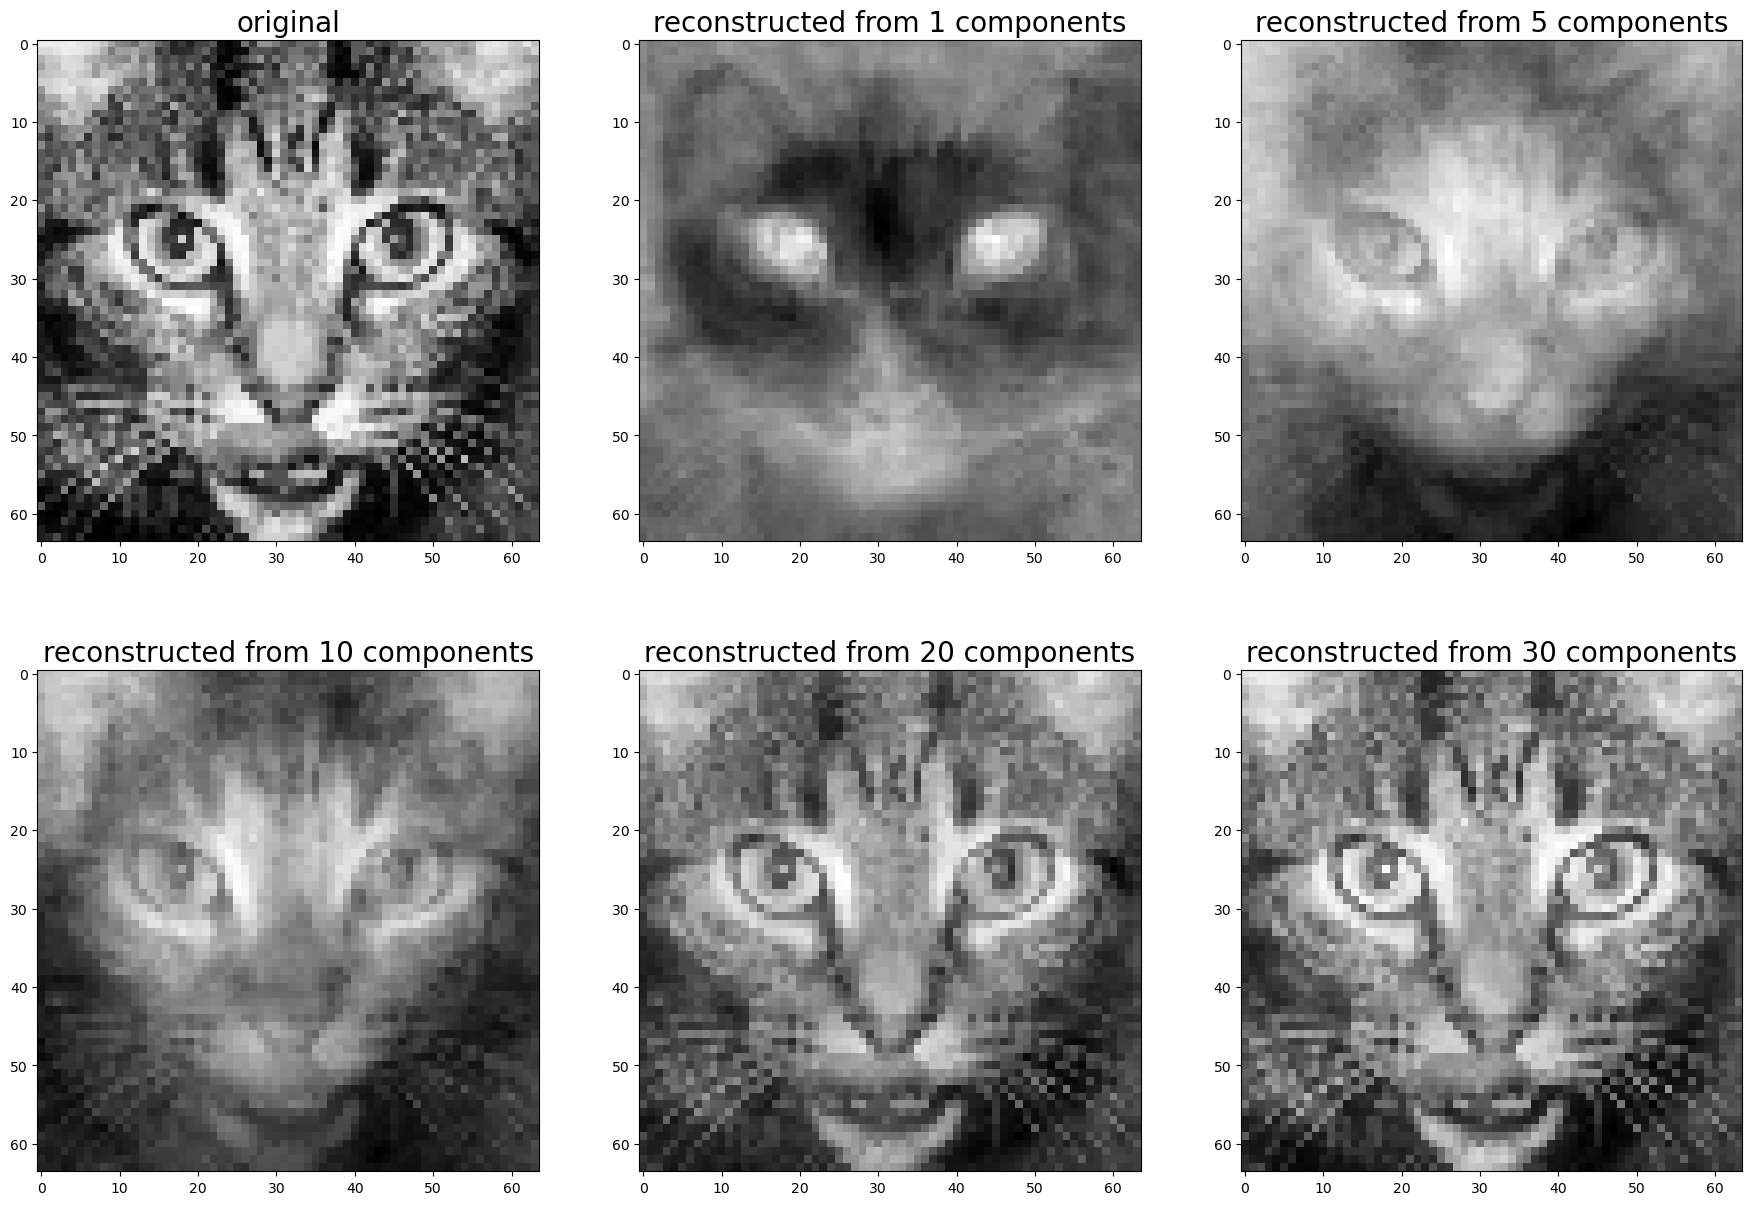

In [76]:
def reconstruct_image(Xred, eigenvecs):
    X_reconstructed = Xred.dot(eigenvecs[:,:Xred.shape[1]].T)

    return X_reconstructed

Xred1 = perform_PCA(X, eigenvecs,1) # reduce dimensions to 1 component
Xred5 = perform_PCA(X, eigenvecs, 5) # reduce dimensions to 5 components
Xred10 = perform_PCA(X, eigenvecs, 10) # reduce dimensions to 10 components
Xred20 = perform_PCA(X, eigenvecs, 20) # reduce dimensions to 20 components
Xred30 = perform_PCA(X, eigenvecs, 30) # reduce dimensions to 30 components
Xrec1 = reconstruct_image(Xred1, eigenvecs) # reconstruct image from 1 component
Xrec5 = reconstruct_image(Xred5, eigenvecs) # reconstruct image from 5 components
Xrec10 = reconstruct_image(Xred10, eigenvecs) # reconstruct image from 10 components
Xrec20 = reconstruct_image(Xred20, eigenvecs) # reconstruct image from 20 components
Xrec30 = reconstruct_image(Xred30, eigenvecs) # reconstruct image from 30 components

fig, ax = plt.subplots(2,3, figsize=(22,15))
ax[0,0].imshow(images[21], cmap='gray')
ax[0,0].set_title('original', size=20)
ax[0,1].imshow(Xrec1[21].reshape(height,width), cmap='gray')
ax[0,1].set_title('reconstructed from 1 components', size=20)
ax[0,2].imshow(Xrec5[21].reshape(height,width), cmap='gray')
ax[0,2].set_title('reconstructed from 5 components', size=20)
ax[1,0].imshow(Xrec10[21].reshape(height,width), cmap='gray')
ax[1,0].set_title('reconstructed from 10 components', size=20)
ax[1,1].imshow(Xrec20[21].reshape(height,width), cmap='gray')
ax[1,1].set_title('reconstructed from 20 components', size=20)
ax[1,2].imshow(Xrec30[21].reshape(height,width), cmap='gray')
ax[1,2].set_title('reconstructed from 30 components', size=20)

<a name='2.7'></a>
### 2.7 - Explained Variance

When choosing the number of components for dimensionality reduction, an important criterion is the **explained variance**.  

- The explained variance measures how much of the total variability in the data is captured by each principal component.  
- The first principal component (largest eigenvalue) explains the most variance.  
- Mathematically, the explained variance of component $i$ is:

$$
\text{Explained Variance}_i = \frac{\lambda_i}{\sum_{j=1}^{55} \lambda_j}
$$

where $\lambda_i$ is the $i$-th eigenvalue.  

Since we only have 55 observations, only 55 eigenvalues are nonzero; the rest are zero and add nothing to the explained variance.  

In practice, the explained variance drops quickly. After ~20 components, it becomes very small. A common rule is to keep enough components to explain around **95% of the variance**.  

To visualize this, we can plot:
- The explained variance for each component.  
- The **cumulative explained variance** using `np.cumsum`.


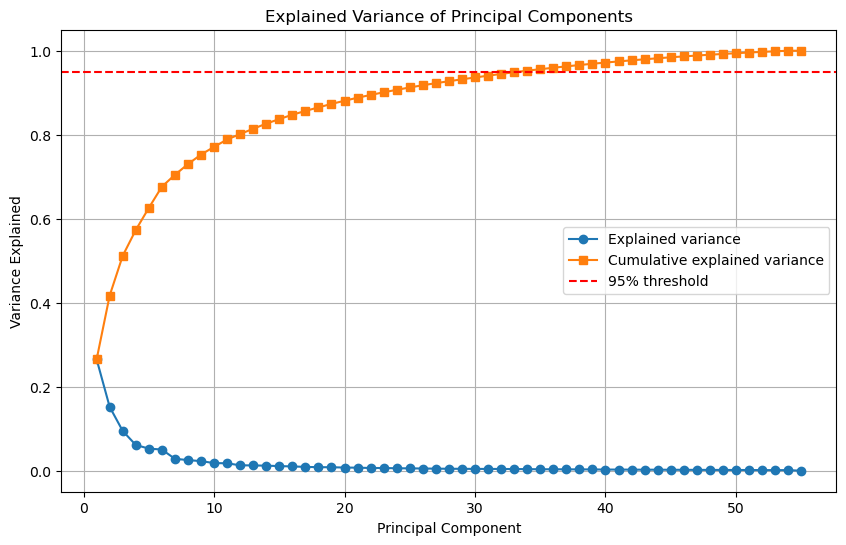

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Explained variance ratio
explained_variance = eigenvals / np.sum(eigenvals)
explained_cum_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,6))

# Individual explained variance
plt.plot(np.arange(1, 56), explained_variance, marker='o', label="Explained variance")

# Cumulative explained variance
plt.plot(np.arange(1, 56), explained_cum_variance, marker='s', label="Cumulative explained variance")

# 95% threshold line
plt.axhline(y=0.95, color='r', linestyle='--', label="95% threshold")

plt.title("Explained Variance of Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.legend()
plt.grid(True)
plt.show()


Let's see how some of the original images look after the reconstruction when using 35 principal components 

Text(0.5, 1.0, 'Reconstructed')

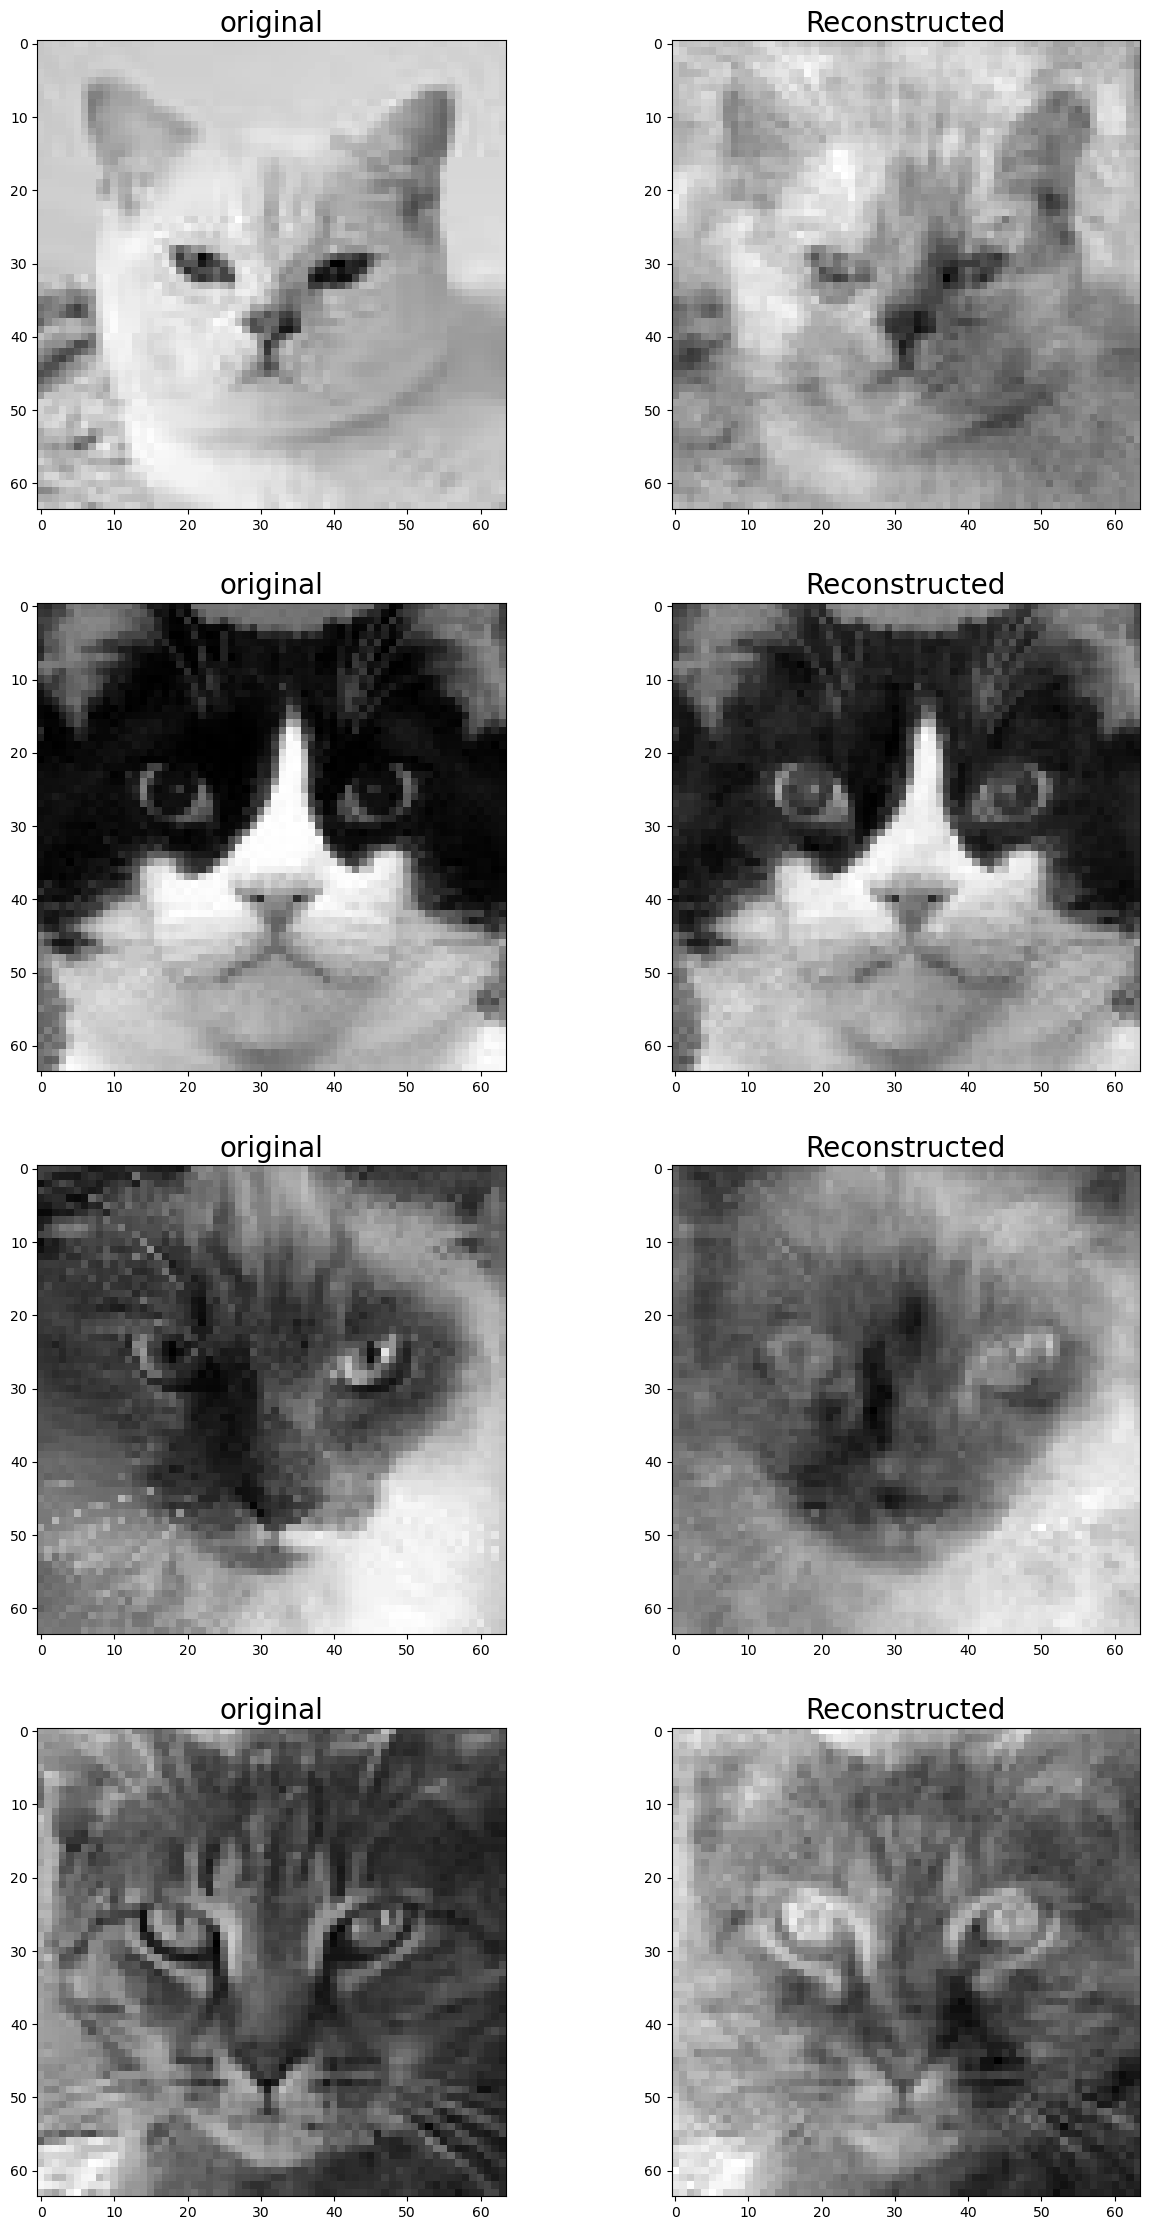

In [81]:
Xred35 = perform_PCA(X, eigenvecs, 35) # reduce dimensions to 35 components
Xrec35 = reconstruct_image(Xred35, eigenvecs) # reconstruct image from 35 components

fig, ax = plt.subplots(4,2, figsize=(15,28))
ax[0,0].imshow(images[0], cmap='gray')
ax[0,0].set_title('original', size=20)
ax[0,1].imshow(Xrec35[0].reshape(height, width), cmap='gray')
ax[0,1].set_title('Reconstructed', size=20)

ax[1,0].imshow(images[15], cmap='gray')
ax[1,0].set_title('original', size=20)
ax[1,1].imshow(Xrec35[15].reshape(height, width), cmap='gray')
ax[1,1].set_title('Reconstructed', size=20)

ax[2,0].imshow(images[32], cmap='gray')
ax[2,0].set_title('original', size=20)
ax[2,1].imshow(Xrec35[32].reshape(height, width), cmap='gray')
ax[2,1].set_title('Reconstructed', size=20)

ax[3,0].imshow(images[54], cmap='gray')
ax[3,0].set_title('original', size=20)
ax[3,1].imshow(Xrec35[54].reshape(height, width), cmap='gray')
ax[3,1].set_title('Reconstructed', size=20)

 **Figure:** PCA image compression.  
The original 64×64 image requires storing **4096 pixel values**.  
With PCA using **35 components**, the same image can be represented with only **35 coefficients**,  
while still reconstructing an approximation of the full grayscale image.  

Most of these reconstructions look pretty good, and we were able to save a lot of memory by reducing the data from 4096 variables to just 35!


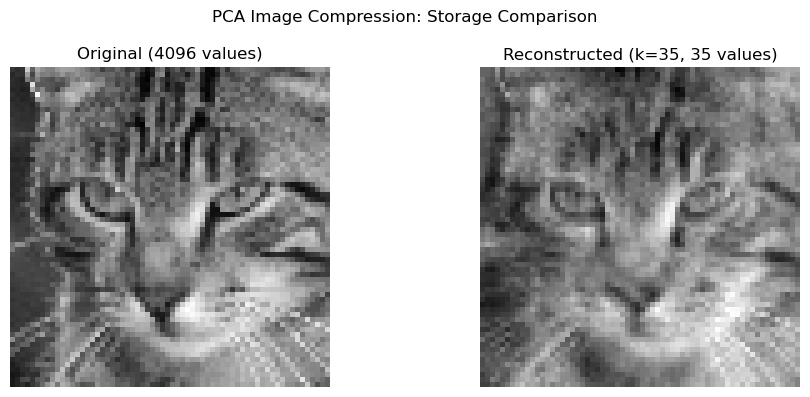

In [92]:
# Pick one image
img_id = 6
mean_img = np.mean(imgs_flatten, axis=0)

original = X[img_id].reshape(64, 64) + mean_img.reshape(64, 64)

# Reconstruct using k components
k = 35
V_k = eigenvecs[:, :k]
Xred_k = X @ V_k
Xrec_k = Xred_k @ V_k.T
reconstructed = Xrec_k[img_id].reshape(64, 64) + mean_img.reshape(64, 64)

# Plot with storage info in titles
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(original, cmap='gray')
ax[0].set_title(f"Original (4096 values)")
ax[0].axis("off")

ax[1].imshow(reconstructed, cmap='gray')
ax[1].set_title(f"Reconstructed (k={k}, {k} values)")
ax[1].axis("off")

plt.suptitle("PCA Image Compression: Storage Comparison")
plt.tight_layout()
plt.savefig("pca_compression_example.png")
plt.show()
